<a href="https://www.kaggle.com/code/mosairulalamtyhan/ensemble-learning?scriptVersionId=314328238" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [5]:
dataset = pd.read_csv("/kaggle/input/datasets/mosairulalamtyhan/car-csv/car_data.csv")
dataset.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


# Feature Engineering 

In [6]:
dataset['MonthlySalary'] = np.round(dataset['AnnualSalary']/12).astype(int)

In [7]:
dataset.head(3)

,User ID,Gender,Age,AnnualSalary,Purchased,MonthlySalary
0,385,Male,35,20000,0,1667
1,681,Male,40,43500,0,3625
2,353,Male,49,74000,0,6167


# Data Visualization

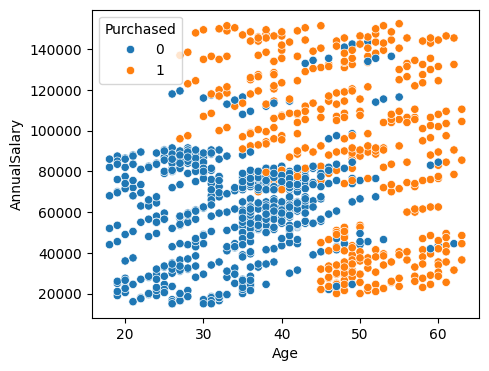

In [8]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=dataset, x='Age', y='AnnualSalary', hue='Purchased')
plt.show()

# Feature And Target Selection

In [9]:
x = dataset[['Age','AnnualSalary','MonthlySalary']]
y = dataset['Purchased']

# Train Test Split

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# StandardScaler

In [11]:
sc = StandardScaler()

x_train_sc = pd.DataFrame(sc.fit_transform(x_train), columns=x.columns)
x_test_sc = sc.transform(x_test)

In [12]:
x_train_sc.head(3)

,Age,AnnualSalary,MonthlySalary
0,-0.180280,2.152137,2.152241
1,1.782584,-1.407626,-1.407507
2,-0.460689,0.516961,0.516841


# Ensemble-Learning  Without Scaling

In [13]:
model_1 = DecisionTreeClassifier()
model_2 = SVC()
model_3 = KNeighborsClassifier()
model_4 = RandomForestClassifier()

ensemble = VotingClassifier(
    estimators=[
        ('dt', model_1),
        ('sv', model_2),
        ('knn', model_3),
        ('rf', model_4)
    ]
)

models = {
        'dt':model_1,
        'sv':model_2,
        'knn':model_3,
        'rf':model_4,
        'esm':ensemble
}


for name,model in models.items():
    model.fit(x_train, y_train)
    print(f'==========={name}=========')
    print('Test Score',model.score(x_test, y_test)*100)
    print('Train Score',model.score(x_train, y_train)*100)

===========dt=========
Test Score 89.5
Train Score 99.25
===========sv=========
Test Score 72.0
Train Score 76.5
===========knn=========
Test Score 80.0
Train Score 86.75
===========rf=========
Test Score 91.5
Train Score 99.25
===========esm=========
Test Score 81.5
Train Score 91.125


# Ensemble-Learning  With Scaling and hyperparameter tuning

In [14]:
model_1 = DecisionTreeClassifier()
model_2 = SVC()
model_3 = KNeighborsClassifier()
model_4 = RandomForestClassifier()

ensemble = VotingClassifier(
    estimators=[
        ('dt', model_1),
        ('sv', model_2),
        ('knn', model_3),
        ('rf', model_4)
    ],
    weights=[1, 3, 2, 2],
    voting='hard'
)

param_grid = {
    'weights': [
        [1,1,1,1],
        [2,1,1,1],
        [1,2,1,2],
        [1,1,2,2],
        [2,2,1,2],
        [3,1,2,1],
        [1,3,2,2]
    ]
}

#  GridSearch
grid = GridSearchCV(ensemble, param_grid, cv=5)
grid.fit(x_train_sc, y_train)

# Best result
print("Best Weights:", grid.best_params_)
print("Best Score:", grid.best_score_)

models = {
        'dt':model_1,
        'sv':model_2,
        'knn':model_3,
        'rf':model_4,
        'esm':ensemble
}


for name,model in models.items():
    model.fit(x_train_sc, y_train)
    print(f'==========={name}=========')
    print('Test Score',model.score(x_test_sc, y_test)*100)
    print('Train Score',model.score(x_train_sc, y_train)*100)

Best Weights: {'weights': [1, 3, 2, 2]}
Best Score: 0.9087500000000001
===========dt=========
Test Score 89.5
Train Score 99.25
===========sv=========
Test Score 91.5
Train Score 90.375
===========knn=========
Test Score 92.0
Train Score 93.0
===========rf=========
Test Score 91.0
Train Score 99.25
===========esm=========
Test Score 92.0
Train Score 94.625


# Accuracy of All Models

In [15]:
pred1 = model_1.predict(x_test_sc)
pred2 = model_2.predict(x_test_sc)
pred3 = model_3.predict(x_test_sc)
pred4 = model_4.predict(x_test_sc)
pred_ensemble = ensemble.predict(x_test_sc)

# Step 8: Accuracy comparison
print("Decision Tree:", accuracy_score(y_test, pred1))
print("SVM:", accuracy_score(y_test, pred2))
print("KNN:", accuracy_score(y_test, pred3))
print("Random Forest:", accuracy_score(y_test, pred4))
print("Ensemble Model:", accuracy_score(y_test, pred_ensemble))

Decision Tree: 0.895
SVM: 0.915
KNN: 0.92
Random Forest: 0.91
Ensemble Model: 0.92


In [16]:
prediction = pd.DataFrame({"Decision Tree":model_1.predict(x_test_sc),
                           "SVM":model_2.predict(x_test_sc),
                           "KNN":model_3.predict(x_test_sc),
                           "Random Forest":model_4.predict(x_test_sc),
                           'Ensemble':ensemble.predict(x_test_sc)
})

In [17]:
prediction

,Decision Tree,SVM,KNN,Random Forest,Ensemble
0,0,0,0,0,0
1,1,1,1,1,1
2,0,0,0,0,0
3,0,1,0,0,0
4,1,1,1,1,1
...,...,...,...,...,...
195,0,0,0,0,0
196,0,0,0,0,0
197,1,1,1,1,1
198,0,0,0,0,0


# Evaluation

In [18]:
print(classification_report(y_test, pred_ensemble))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       112
           1       0.94      0.88      0.91        88

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



In [19]:
pd.DataFrame(confusion_matrix(y_test, pred_ensemble))

,0,1
0,107,5
1,11,77
